In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import sys
import os
from pathlib import Path

# move upward until we find repo root
repo_root = Path.cwd()

while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

sys.path.append(str(repo_root))
from config import config
from DataPipeline.utils.bets_utils import generate_bets 

In [297]:
non_merged = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\non_merged_features\non_merged_stats.csv')
non_merged[non_merged['fighter_red'] == 'Ludovit Klein'][['winner']]

,winner
230,Tofiq Musayev


In [298]:
df_ml_history = pd.read_csv(config.ml_history_fp)
print(df_ml_history.shape)
df_ml_history = df_ml_history.drop_duplicates(subset=['fighter_red', 'fighter_blue', 'date'], keep='first')
print(df_ml_history.shape)

(38, 23)
(38, 23)


In [115]:
df_features = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\stats_odds_merged.csv')
for c in df_features.columns:
    print(c)

td_defense_pct_red
td_total_attempted_against_red
td_total_landed_against_red
td_defense_pct_blue
td_total_attempted_against_blue
td_total_landed_against_blue
sig_str_defense_pct_red
sig_str_total_attempted_against_red
sig_str_total_landed_against_red
sig_str_defense_pct_blue
sig_str_total_attempted_against_blue
sig_str_total_landed_against_blue
td_accuracy_pct_red
td_accuracy_pct_blue
sig_str_accuracy_pct_red
sig_str_accuracy_pct_blue
kd_pm_red
kd_total_red
kd_pm_blue
kd_total_blue
sig_str_landed_pm_red
sig_str_landed_total_red
sig_str_landed_pm_blue
sig_str_landed_total_blue
sig_str_absorbed_pm_red
sig_str_absorbed_total_red
sig_str_absorbed_pm_blue
sig_str_absorbed_total_blue
sig_str_attempted_pm_red
sig_str_attempted_total_red
sig_str_attempted_pm_blue
sig_str_attempted_total_blue
leg_str_pm_red
leg_str_total_red
leg_str_pm_blue
leg_str_total_blue
head_str_pm_red
head_str_total_red
head_str_pm_blue
head_str_total_blue
body_str_pm_red
body_str_total_red
body_str_pm_blue
body_str_tot

C:\Users\jcmar\AppData\Local\Temp\ipykernel_46196\1960192368.py:1: DtypeWarning: Columns (86,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\stats_odds_merged.csv')


In [43]:
df_ml_history['fstar_o']

Index(['net_odds_open', 'net_odds_close1', 'net_odds_close2', 'winner_bool',
       'fighter_red', 'fighter_blue', 'pred_name_open', 'pred_name_close1',
       'pred_name_close2', 'pred_winner_open', 'pred_winner_close1_stack',
       'pred_winner_close2_stack', 'open_red', 'open_blue', 'close1_red',
       'close1_blue', 'close2_red', 'close2_blue', 'fstar_open',
       'fstar_close1', 'fstar_close2', 'date', 'winner_name'],
      dtype='object')

In [302]:
df_parlay = pd.read_csv(config.parlay_history_fp)
df_parlay.columns

Index(['open_net_fstar', 'close1_net_fstar', 'close2_net_fstar', 'open_red',
       'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'open_net_odds', 'close1_net_odds', 'close2_net_odds', 'open_fstar',
       'close1_fstar', 'close2_fstar', 'choice_fighter_bool_open',
       'choice_fighter_bool_close1', 'choice_fighter_bool_close2',
       'winner_bool_open', 'winner_bool_close1', 'winner_bool_close2',
       'choice_fighter_name_open', 'choice_fighter_name_close1',
       'choice_fighter_name_close2', 'fight_index_open',
       'fight_index_close1_stack', 'fight_index_close2_stack', 'winner_name',
       'winner_name_close1', 'winner_name_close2', 'date'],
      dtype='object')

In [300]:
df_ml_history[['fstar_open', 'fstar_close1','fstar_close2', 'pred_winner_open', 'pred_name_close1', 'pred_winner_close1', 'pred_winner_close2', 'winner_bool']]

,fstar_open,fstar_close1,fstar_close2,pred_winner_open,pred_name_close1,pred_winner_close1,pred_winner_close2,winner_bool
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,0.133787,0.180196,0.182653,1.0,nurullo aliev,1.0,1.0,1.0
2,0.056227,0.000000,0.000000,1.0,magomed ankalaev,1.0,1.0,1.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,0.058350,0.042524,0.079345,1.0,rizvan kuniev,1.0,1.0,1.0
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,0.017226,0.000000,0.000000,0.0,sam patterson,0.0,0.0,0.0
8,0.057575,0.028930,0.026537,0.0,axel sola,0.0,0.0,0.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [303]:
df_parlay[['date','winner_name_close1','winner_name_close2', 'winner_bool_open', 'winner_bool_close1', 'choice_fighter_name_open', 'choice_fighter_name_close1', 'fight_index_open', 'fight_index_close1_stack', 'fight_index_close2_stack']]


,date,winner_name_close1,winner_name_close2,winner_bool_open,winner_bool_close1,choice_fighter_name_open,choice_fighter_name_close1,fight_index_open,fight_index_close1_stack,fight_index_close2_stack
0,2026-07-25,Ramazan Temirov,Ramazan Temirov,1,0,nurullo aliev,steve erceg,1,10,10
1,2026-07-25,Valter Walker,Valter Walker,0,1,steve erceg,valter walker,10,11,11
2,2026-08-01,Robert Valentin,Robert Valentin,0,0,ludovit klein,dusko todorovic,1,5,5
3,2026-08-01,Uros Medic,Uros Medic,0,1,navajo stirling,uros medic,3,2,2
4,2026-08-08,Diyar Nurgozhay,Diyar Nurgozhay,1,1,diyar nurgozhay,diyar nurgozhay,0,0,0
5,2026-08-08,Diego Ferreira,Diego Ferreira,1,1,diego ferreira,diego ferreira,8,8,8


In [324]:
from collections import defaultdict
def american_to_decimal(odds):
    odds = np.asarray(odds)
    return np.where(
        odds > 0, 
        1 + odds / 100, 
        1 + 100 / abs(odds)
    )

def returns_by_date(starting_bankroll=500):
    
    df_ml = pd.read_csv(config.ml_history_fp)
    df_parlay = pd.read_csv(config.parlay_history_fp)

    types = ['open', 'close1', 'close2']

    df_ml = pd.read_csv(config.ml_history_fp)
    df_parlay = pd.read_csv(config.parlay_history_fp)

    bankroll_data = defaultdict(list)
    parlay_data = defaultdict(list)
    ml_data = defaultdict(list)
    
    ml_data['date'] = df_ml['date']
    bankroll_data['date'] = df_parlay.groupby('date')['date'].first()
    parlay_data['date'] = df_parlay.groupby('date')['date'].first()

    for type_ in types: 

        date_index = df_ml['date']
        win_bet = pd.Series(np.nan, index=date_index)
        mask = ~pd.isna(df_ml[f'pred_winner_{type_}'])

        win_bet = pd.Series(np.nan, index=date_index)
        mask = df_ml[f"pred_winner_{type_}"].notna().to_numpy()

        win_bet.iloc[mask] = (
            df_ml.loc[mask, f"pred_winner_{type_}"].astype(int).to_numpy()
            == df_ml.loc[mask, "winner_bool"].astype(int).to_numpy()
        )

        choice_stake = pd.Series(
            np.array(
                df_ml[f'fstar_{type_}'].fillna(0)
            ), 
        index=date_index
        )
        net_stake = choice_stake.where(win_bet, -choice_stake)

        choice_odds = pd.Series(
            np.where(
                df_ml[f'pred_winner_{type_}'] == 1, 
                american_to_decimal(df_ml[f'{type_}_red'])-1, 
                american_to_decimal(df_ml[f'{type_}_blue'])-1
            ),
        index=date_index
        )
        choice_odds = choice_odds.fillna(0)
        net_odds = choice_odds.where(win_bet, -1)

        ml_data[f'net_stake_{type_}'] = net_stake.where(mask, 0)
        ml_data[f'net_odds_{type_}'] = net_odds.where(mask, 0)


        date_index = df_parlay['date']

        leg_win = pd.Series(
            (df_parlay[f'choice_fighter_bool_{type_}'] == df_parlay[f'winner_bool_{type_}']).to_numpy(), 
            index=date_index
        )
        win_parlay = leg_win.groupby(level=0).all()
        single_date_index = win_parlay.index

        choice_parlay_odds = pd.Series(
            np.where(
                df_parlay[f'choice_fighter_bool_{type_}'] == 1,
                american_to_decimal(df_parlay[f'{type_}_red']),
                american_to_decimal(df_parlay[f'{type_}_blue'])
            ), 
            index=date_index
        ).fillna(0)

        parlay_stake = pd.Series(
            df_parlay.groupby('date')[f'{type_}_fstar'].first().fillna(0),
            index=single_date_index
        )
        parlay_net_stake = parlay_stake.where(win_parlay, -parlay_stake)

        parlay_odds = pd.Series(np.array(choice_parlay_odds.groupby(level=0).prod() - 1), index=single_date_index)
        parlay_net_odds = parlay_odds.where(win_parlay, -parlay_odds)

        parlay_data[f'net_odds_{type_}'] = parlay_net_odds.copy()
        parlay_data[f'net_stake_{type_}'] = parlay_net_stake.copy()

        bankroll = starting_bankroll
        profits = []

        for date in date_index.unique():

            wins = win_bet.loc[date]
            stakes = choice_stake.loc[date]
            odds = choice_odds.loc[date]

            profit_ml = np.where(
                wins, 
                stakes * bankroll * odds, 
                -stakes * bankroll
            )

            wins_parlay = win_parlay.loc[date]
            stakes_parlay = parlay_stake.loc[date]
            odds_parlay = parlay_odds.loc[date]

            profit_parlay = stakes_parlay * odds_parlay * bankroll if wins_parlay else -stakes_parlay * bankroll 

            total_profit = profit_ml.sum() + profit_parlay
            profits.append(total_profit)
            bankroll += total_profit.sum()

        bankroll_data[f'bankroll_{type_}'] = profits

    other_info = df_ml[[
        'open_red', 'open_blue', 'close1_red', 'close2_blue',
        'fighter_red', 'fighter_blue', 'pred_winner_open', 'pred_winner_close1', 'pred_winner_close2',
        'winner_bool', 'winner_name'
    ]].reset_index(drop=True)

    ml_results = {
        key: value.to_numpy()
        for key, value in dict(ml_data).items()
    }

    ml_results = pd.DataFrame(ml_results)
    ml_results = pd.concat([ml_results, other_info], axis=1)

    parlay_results = pd.DataFrame(dict(parlay_data))
    bankroll_results = pd.DataFrame(dict(bankroll_data))

    return ml_results, parlay_results, bankroll_results


ml_results, parlay_results, bankroll_results = returns_by_date()


C:\Users\jcmar\AppData\Local\Temp\ipykernel_46196\903634777.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True  True  True False  True False  True  True  True False
  True  True  True  True  True  True  True  True False  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  win_bet.iloc[mask] = (
C:\Users\jcmar\AppData\Local\Temp\ipykernel_46196\903634777.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True  True  True False  True False  True  True  True False
  True  True  True  True  True  True  True  True  True  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  win_bet.iloc[mask] = (
C:\Users\jcmar\AppData\Local\Temp\ipykernel_46196\903634777.py:37: FutureWarning: Setting an item of incompa

In [325]:
ml_results.head()

,date,net_stake_open,net_odds_open,net_stake_close1,net_odds_close1,net_stake_close2,net_odds_close2,open_red,open_blue,close1_red,close2_blue,fighter_red,fighter_blue,pred_winner_open,pred_winner_close1,pred_winner_close2,winner_bool,winner_name
0,2026-07-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,285.0,-350.0,420.0,-600.0,cody gibson,abdul hussein,NaN,NaN,NaN,0.0,Abdul Hussein
1,2026-07-25,0.133787,0.581395,0.180196,0.425532,0.182653,0.444444,-172.0,147.0,-235.0,193.0,nurullo aliev,mike davis,1.0,1.0,1.0,1.0,Nurullo Aliev
2,2026-07-25,0.056227,0.333333,0.000000,0.178571,0.000000,0.182149,-300.0,250.0,-560.0,410.0,magomed ankalaev,bogdan guskov,1.0,1.0,1.0,1.0,Magomed Ankalaev
3,2026-07-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-275.0,235.0,-286.0,215.0,magomed zaynukov,damian rzepecki,NaN,NaN,NaN,1.0,Magomed Zaynukov
4,2026-07-25,0.058350,0.400000,0.042524,0.285714,0.079345,0.322581,-250.0,210.0,-350.0,275.0,rizvan kuniev,tyrell fortune,1.0,1.0,1.0,1.0,Rizvan Kuniev


In [315]:
parlay_results.head()

,date,net_odds_open,net_stake_open,net_odds_close1,net_stake_close1,net_odds_close2,net_stake_close2
date,,,,,,,
2026-07-25,2026-07-25,-1.635659,-0.113580,-1.759834,-0.107998,-2.048662,-0.098789
2026-08-01,2026-08-01,-1.534483,-0.117710,-1.767241,-0.102745,-2.085714,-0.093121
2026-08-08,2026-08-08,3.255122,0.077132,1.449229,0.117729,1.553571,0.113459


In [317]:
df_parlay.tail()[['choice_fighter_name_open',	'choice_fighter_name_close1',	'choice_fighter_name_close2']]

,choice_fighter_name_open,choice_fighter_name_close1,choice_fighter_name_close2
1,steve erceg,valter walker,valter walker
2,ludovit klein,dusko todorovic,dusko todorovic
3,navajo stirling,uros medic,uros medic
4,diyar nurgozhay,diyar nurgozhay,diyar nurgozhay
5,diego ferreira,diego ferreira,diego ferreira


In [331]:
import seaborn as sns 
BASE_DIR = config.base_dir  

def plot_returns(ml_results, parlay_results, bankroll_results):

    types = ['open', 'close1', 'close2']
    fig, axes = plt.subplots(2, len(types), figsize=(15,6))
    
    for i, type_ in enumerate(types):
        # ML percent returns
        net_odds = ml_results[f'net_odds_{type_}']
        sns.histplot(net_odds, ax=axes[0, i], kde=False, color='skyblue')
        avg_ml = np.mean(net_odds)
        total_ml = np.sum(net_odds)
        axes[0, i].set_title(f"ML {type_} — Avg: {avg_ml:.2f}, Total: {total_ml:.2f}")
        
        # Parlay percent returns
        net_odds = parlay_results[f'net_odds_{type_}']
        sns.histplot(net_odds, ax=axes[1, i], kde=False, color='salmon')
        avg_parlay = np.mean(net_odds)
        total_parlay = np.sum(net_odds)
        axes[1, i].set_title(f"Parlay {type_} — Avg: {avg_parlay:.2f}, Total: {total_parlay:.2f}")

    plt.tight_layout()


    fig, axes = plt.subplots(nrows=3, figsize=(15,6))
    date = bankroll_results['date']
    for i, type_ in enumerate(types): 
        bankroll = bankroll_results[f'bankroll_{type_}']
        axes[i].plot(date, bankroll)
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel('Bankroll')
        axes[i].set_title(f'Bankroll for odds {type_}')

    plt.tight_layout()


def data_analysis(ml_results, parlay_results):

    accuracies = defaultdict(list)
    types = ['open', 'close1', 'close2']

    for type_ in types: 
        accuracy_all = (ml_results[f'pred_winner_{type_}'] == ml_results['winner_bool']).mean()
        accuracies[f'accuracy_all_{type_}'].append(accuracy_all)

        bets_only = ml_results[ml_results[f'net_stake_{type_}'] > 0]
        accuracy_bets = (bets_only[f'pred_winner_{type_}'] == bets_only['winner_bool']).mean()
        accuracies[f'accuracy_bets_{type_}'].append(accuracy_bets)

        parlay_accuracy = (parlay_results[f'net_odds_{type_}'] > 0).mean()
        accuracies[f'accuracy_parlays_{type_}'].append(parlay_accuracy)

    return pd.DataFrame(accuracies)


In [330]:
ml_results.columns

Index(['date', 'net_stake_open', 'net_odds_open', 'net_stake_close1',
       'net_odds_close1', 'net_stake_close2', 'net_odds_close2', 'open_red',
       'open_blue', 'close1_red', 'close2_blue', 'fighter_red', 'fighter_blue',
       'pred_winner_open', 'pred_winner_close1', 'pred_winner_close2',
       'winner_bool', 'winner_name'],
      dtype='object')

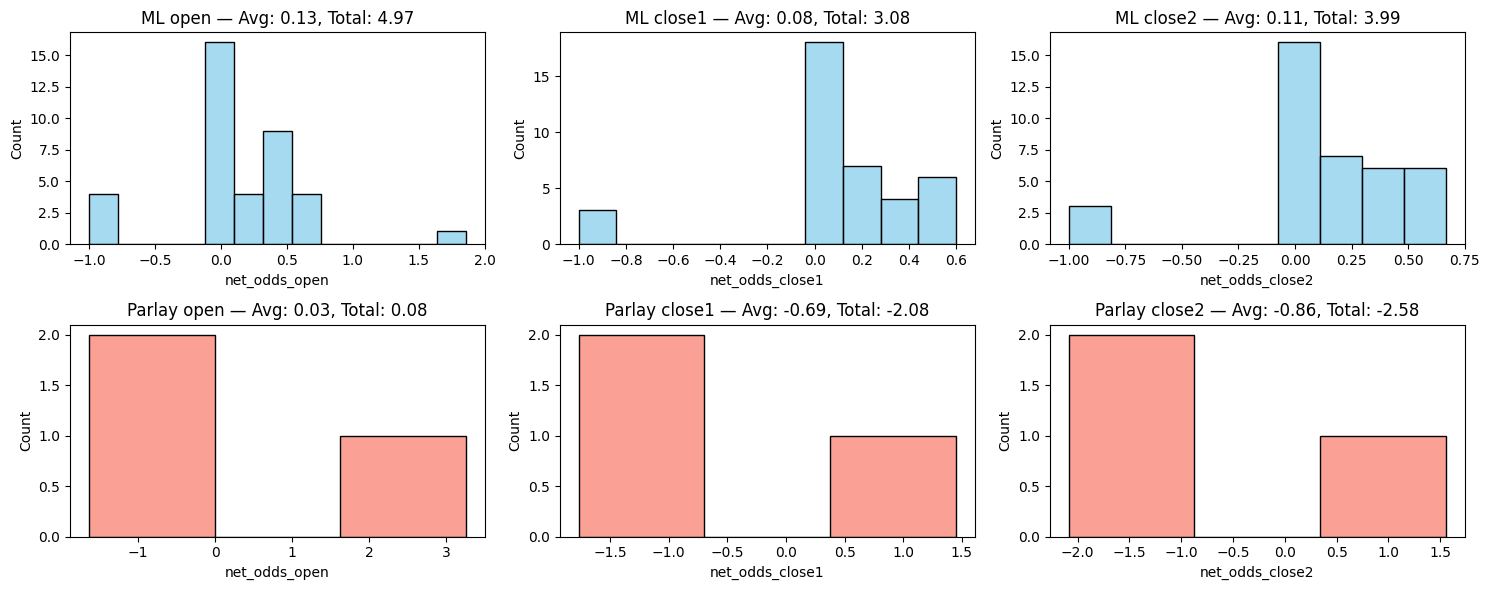

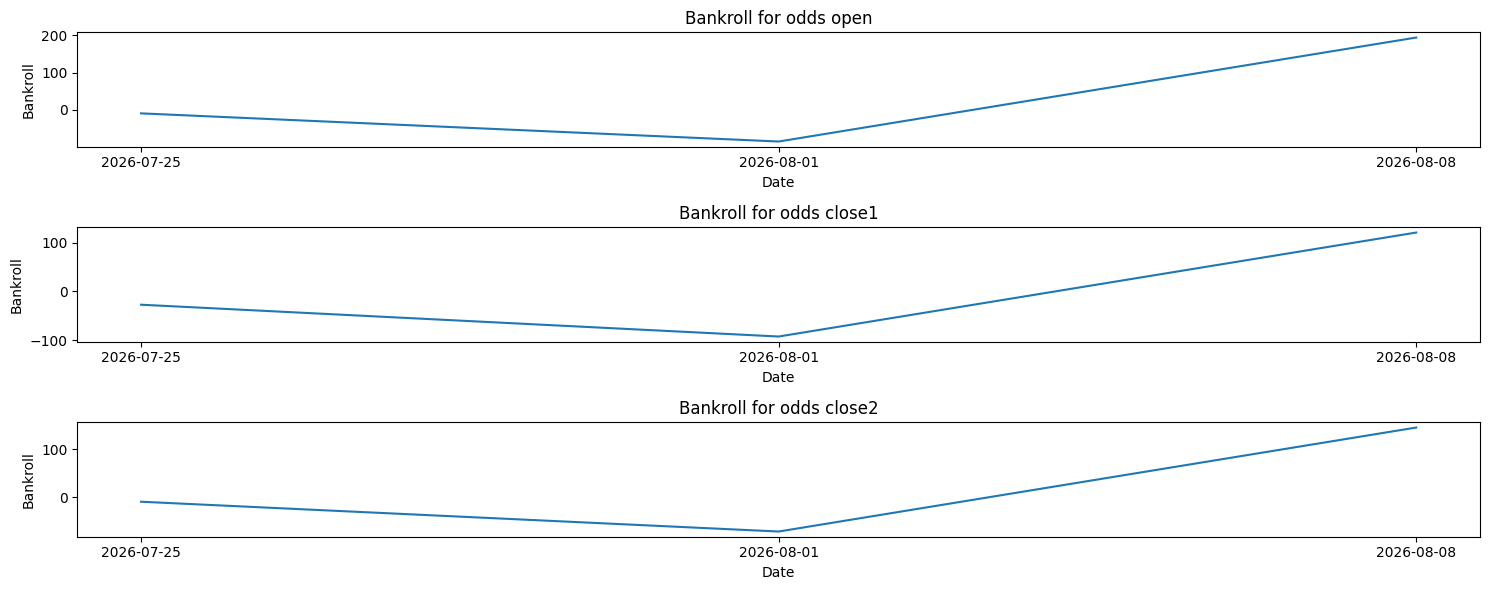

In [332]:

plot_returns(ml_results, parlay_results, bankroll_results)
df_bankroll = data_analysis(ml_results, parlay_results)

In [333]:
df_bankroll

,accuracy_all_open,accuracy_bets_open,accuracy_parlays_open,accuracy_all_close1,accuracy_bets_close1,accuracy_parlays_close1,accuracy_all_close2,accuracy_bets_close2,accuracy_parlays_close2
0,0.473684,1.0,0.333333,0.5,1.0,0.333333,0.5,1.0,0.333333


In [174]:
df_parlay.columns

Index(['open_net_fstar', 'close1_net_fstar', 'close2_net_fstar', 'open_red',
       'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
       'open_net_odds', 'close1_net_odds', 'close2_net_odds', 'open_fstar',
       'close1_fstar', 'close2_fstar', 'choice_fighter_bool_open',
       'choice_fighter_bool_close1', 'choice_fighter_bool_close2',
       'winner_bool_open', 'winner_bool_close1', 'winner_bool_close2',
       'choice_fighter_name_open', 'choice_fighter_name_close1',
       'choice_fighter_name_close2', 'fight_index_open',
       'fight_index_close1_stack', 'fight_index_close2_stack', 'winner_name',
       'winner_name_close1', 'winner_name_close2', 'date'],
      dtype='object')

In [171]:
df_ml_bets.head()[['open_wager', 'open_profit', 'open_red', 'open_blue', 'pred_winner_open']]

,open_wager,open_profit,open_red,open_blue,pred_winner_open
0,66.896073,38.893066,-172.0,147.0,1
1,0.000000,0.000000,285.0,-350.0,0
2,61.145726,-61.145726,-150.0,130.0,1
3,0.000000,0.000000,-275.0,235.0,0
4,29.174784,11.669914,-250.0,210.0,1


In [59]:
df_stats_missing = pd.read_csv(config.non_merged_stats_fp)
print(df_stats_missing.shape[0])

df_stats_missing = df_stats_missing.drop_duplicates(subset=['fighter_red', 'fighter_blue', 'event_date'])
print(df_stats_missing.shape)

missing_odds_prev = pd.read_csv(config.non_merged_odds_fp)
print(missing_odds_prev.shape)

missing_odds_prev = missing_odds_prev.drop_duplicates(subset=['event_date', 'blue_fighter', 'red_fighter'])
print(missing_odds_prev.shape)

238
(238, 54)
(254, 11)
(254, 11)


In [27]:
missing_odds_prev.columns

Index(['blue_fighter', 'open_blue', 'close1_blue', 'close2_blue',
       'red_fighter', 'open_red', 'close1_red', 'close2_red', 'event_date',
       'og_blue_name', 'og_red_fighter'],
      dtype='object')

In [19]:
df_stats_missing.head()

,title_fight,event_name,event_date,event_location,fight_url,weight_class,method,round,fight_time,performance_bonus_winner,...,head_red,head_blue,body_red,body_blue,leg_red,leg_blue,distance_red,distance_blue,total_strikes_red,total_strikes_blue
0,0,UFC Fight Night: Evloev vs. Murphy,2026-03-21,"London, England, United Kingdom",http://ufcstats.com/fight-details/346e3897c2ea...,Featherweight,M-DEC,5,5:00,0,...,47 of 134,45 of 175,33 of 44,24 of 38,6 of 11,20 of 26,80 of 178,89 of 238,124 of 234,89 of 239
1,0,UFC Fight Night: Evloev vs. Murphy,2026-03-21,"London, England, United Kingdom",http://ufcstats.com/fight-details/fa534aaa5b99...,Featherweight,U-DEC,3,5:00,0,...,65 of 134,48 of 158,31 of 36,13 of 21,4 of 7,0 of 1,90 of 166,58 of 169,113 of 192,107 of 233
2,0,UFC Fight Night: Evloev vs. Murphy,2026-03-21,"London, England, United Kingdom",http://ufcstats.com/fight-details/5ee11b727e89...,Welterweight,U-DEC,3,5:00,0,...,17 of 38,4 of 50,4 of 8,4 of 6,6 of 9,4 of 8,27 of 55,10 of 60,33 of 61,25 of 78
3,0,UFC Fight Night: Evloev vs. Murphy,2026-03-21,"London, England, United Kingdom",http://ufcstats.com/fight-details/43e26b46cbb5...,Light Heavyweight,"KO/TKO, Punch",1,0:28,1,...,9 of 12,0 of 3,0 of 0,0 of 0,1 of 1,0 of 1,2 of 5,0 of 4,10 of 13,0 of 4
4,0,UFC Fight Night: Evloev vs. Murphy,2026-03-21,"London, England, United Kingdom",http://ufcstats.com/fight-details/562d916f5591...,Middleweight,U-DEC,3,5:00,0,...,8 of 31,18 of 52,0 of 0,6 of 12,2 of 3,30 of 35,9 of 33,51 of 92,40 of 94,78 of 125


In [4]:
df_ml_history = df_ml_history.drop_duplicates(subset=['fighter_red', 'fighter_blue'])
print(df_ml_history.shape)

(192, 20)


In [2]:
folder_path = r"C:\Users\jcmar\my_files\SportsBetting\Data\upcoming_events\event_features"

file_path = os.path.join(folder_path, "upcoming_odds_stats_2026-06-06.csv")
print(file_path)

upcoming_fp = fr'{file_path}'
upcoming_df = pd.read_csv(upcoming_fp)  

df_bets_all, df_parlay_all = generate_bets(upcoming_df)




C:\Users\jcmar\my_files\SportsBetting\Data\upcoming_events\event_features\upcoming_odds_stats_2026-06-06.csv
Constant-like columns: ['const']
Constant-like columns: ['const']
Constant-like columns: ['const']
0     0.282688
1     0.205283
2     0.219648
3     0.098323
4     0.014437
5     0.201905
6     0.007705
7     0.120093
8     0.102102
9          NaN
10    0.257567
11    0.000000
Name: fstar_scaled, dtype: float64
0     0.283114
1     0.205430
2     0.218685
3     0.065025
4     0.092367
5     0.219545
6     0.000000
7     0.119642
8     0.106465
9          NaN
10    0.260677
11    0.000000
Name: fstar_scaled, dtype: float64


In [4]:
upcoming_df[['open_red', 'open_blue', 'close2_red', 'close2_blue']] 

,open_red,open_blue,close2_red,close2_blue
0,-450.0,350.0,-520.0,400.0
1,-350.0,285.0,-225.0,195.0
2,-185.0,160.0,-275.0,250.0
3,220.0,-260.0,-250.0,220.0
4,400.0,-550.0,550.0,-549.0
5,-250.0,210.0,-155.0,135.0
6,-110.0,-110.0,-132.0,115.0
7,-110.0,-110.0,100.0,-120.0
8,330.0,-400.0,165.0,-175.0
9,-900.0,600.0,-350.0,310.0
